In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

In [ ]:
ann_all = pd.read_csv('results/annual_results_all.csv')

gdp = pd.read_csv('data/GDP_ppp.csv')
gdp

,Country Code,2010,2011,2012,2013,2014,2015,2016,2017,2018,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,ABW,3.491496e+09,3.611815e+09,3.562338e+09,3.711894e+09,3.723029e+09,3.935242e+09,4.017882e+09,4.098240e+09,4.098240e+09,...,5.521483e+09,5.635380e+09,5.751627e+09,5.870271e+09,5.991363e+09,6.114953e+09,6.241092e+09,6.369834e+09,6.501230e+09,6.635338e+09
1,AFG,5.711689e+10,5.736041e+10,6.467518e+10,6.829747e+10,7.015826e+10,7.117648e+10,7.278529e+10,7.471192e+10,7.560042e+10,...,8.393724e+10,8.576707e+10,8.763679e+10,8.954727e+10,9.149940e+10,9.349409e+10,9.553226e+10,9.761487e+10,9.974287e+10,1.019173e+11
2,AGO,1.796660e+11,1.859040e+11,2.017850e+11,2.117820e+11,2.219960e+11,2.240900e+11,2.183090e+11,2.179870e+11,2.136200e+11,...,2.108629e+11,2.089685e+11,2.070911e+11,2.052306e+11,2.033868e+11,2.015596e+11,1.997488e+11,1.979543e+11,1.961758e+11,1.944134e+11
3,ALB,3.131347e+10,3.211052e+10,3.256560e+10,3.289192e+10,3.347557e+10,3.421830e+10,3.535263e+10,3.669682e+10,3.817179e+10,...,6.981139e+10,7.196758e+10,7.419037e+10,7.648182e+10,7.884403e+10,8.127921e+10,8.378960e+10,8.637753e+10,8.904538e+10,9.179564e+10
4,ARE,4.695810e+11,5.021160e+11,5.246300e+11,5.511400e+11,5.754460e+11,6.045650e+11,6.226070e+11,6.373850e+11,6.449690e+11,...,1.121289e+12,1.155249e+12,1.190237e+12,1.226284e+12,1.263423e+12,1.301687e+12,1.341110e+12,1.381727e+12,1.423574e+12,1.466689e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,VUT,7.296662e+08,7.525622e+08,7.601633e+08,7.637255e+08,7.876015e+08,7.905280e+08,8.275933e+08,8.798609e+08,9.053789e+08,...,1.568409e+09,1.623347e+09,1.680210e+09,1.739064e+09,1.799980e+09,1.863030e+09,1.928288e+09,1.995832e+09,2.065742e+09,2.138101e+09
183,WSM,1.117539e+09,1.163399e+09,1.115880e+09,1.112060e+09,1.112640e+09,1.160449e+09,1.254750e+09,1.267830e+09,1.252195e+09,...,2.059999e+09,2.128325e+09,2.198917e+09,2.271851e+09,2.347203e+09,2.425056e+09,2.505490e+09,2.588592e+09,2.674450e+09,2.763156e+09
184,ZAF,6.975100e+11,7.196110e+11,7.368540e+11,7.551690e+11,7.658450e+11,7.759690e+11,7.811260e+11,7.901710e+11,8.019250e+11,...,9.111122e+11,9.197605e+11,9.284909e+11,9.373041e+11,9.462010e+11,9.551823e+11,9.642489e+11,9.734016e+11,9.826411e+11,9.919683e+11
185,ZMB,4.252590e+10,4.489230e+10,4.830303e+10,5.074583e+10,5.312986e+10,5.468146e+10,5.674660e+10,5.873519e+10,6.110486e+10,...,1.157219e+11,1.193502e+11,1.230923e+11,1.269518e+11,1.309322e+11,1.350375e+11,1.392714e+11,1.436381e+11,1.481418e+11,1.527866e+11


In [5]:
usa_df = ann_all[(ann_all['Country Code'] == 'USA') & (ann_all['scenario'] == 'val')].sort_values('year').copy()
usa_df = usa_df.groupby('year')['GDP_loss'].sum().reset_index()
usa_df = pd.concat([pd.DataFrame({'year': [2019], 'GDP_loss': [0]}), usa_df], ignore_index=True)

gdp_years = [str(y) for y in range(2019, 2051)]
usa_gdp = gdp[gdp['Country Code'] == 'USA'].copy()
usa_gdp = usa_gdp[gdp_years].T.reset_index()
usa_gdp.columns = ['year', 'GDP_SQ']
usa_gdp['year'] = usa_gdp['year'].astype(int)

usa = usa_df.merge(usa_gdp, on='year', how='left')
usa['GDP_CF'] = usa['GDP_loss'] + usa['GDP_SQ']

usa

,year,GDP_loss,GDP_SQ,GDP_CF
0,2019,0.000000e+00,2.056360e+13,2.056360e+13
1,2020,7.675618e+09,1.986350e+13,1.987118e+13
2,2021,1.909554e+10,1.918715e+13,1.920624e+13
3,2022,3.465261e+10,2.027640e+13,2.031105e+13
4,2023,4.815611e+10,2.102825e+13,2.107641e+13
5,2024,6.001556e+10,2.150139e+13,2.156140e+13
6,2025,7.274687e+10,2.181058e+13,2.188332e+13
7,2026,8.082357e+10,2.217721e+13,2.225804e+13
8,2027,9.021712e+10,2.255423e+13,2.264444e+13
9,2028,9.784532e+10,2.293765e+13,2.303549e+13


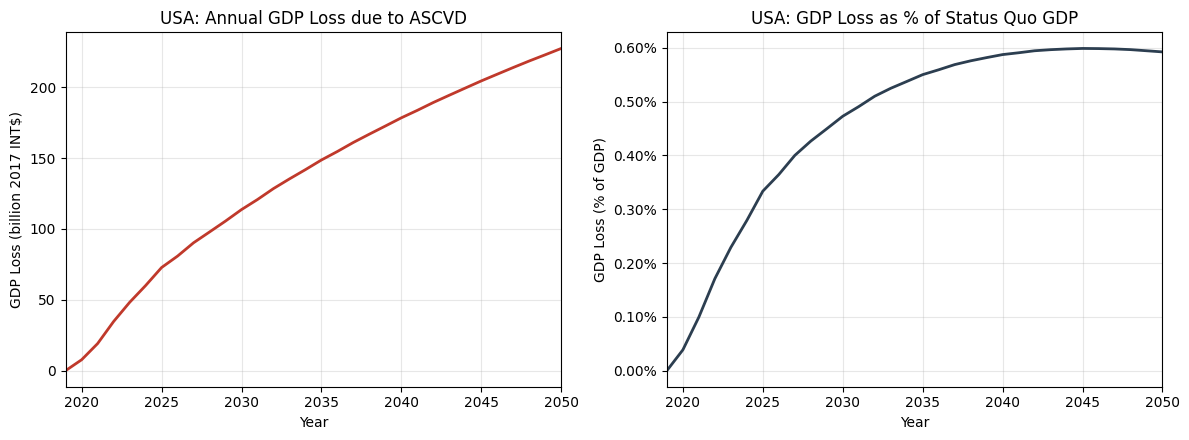

In [14]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

years = usa['year'].values

loss_billion = usa['GDP_loss'].values / 1e9
axes[0].plot(years, loss_billion, color='#c0392b', linewidth=2)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('GDP Loss (billion 2017 INT$)')
axes[0].set_title('USA: Annual GDP Loss due to ASCVD')
axes[0].set_xlim(2019, 2050)
axes[0].grid(alpha=0.3)

loss_pct = (usa['GDP_loss'].values / usa['GDP_SQ'].values) * 100
axes[1].plot(years, loss_pct, color='#2c3e50', linewidth=2)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('GDP Loss (% of GDP)')
axes[1].set_title('USA: GDP Loss as % of Status Quo GDP')
axes[1].set_xlim(2019, 2050)
axes[1].grid(alpha=0.3)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

plt.tight_layout()
# plt.savefig('tables/usa_gdp_loss_detail.png', dpi=300, bbox_inches='tight')
plt.show()

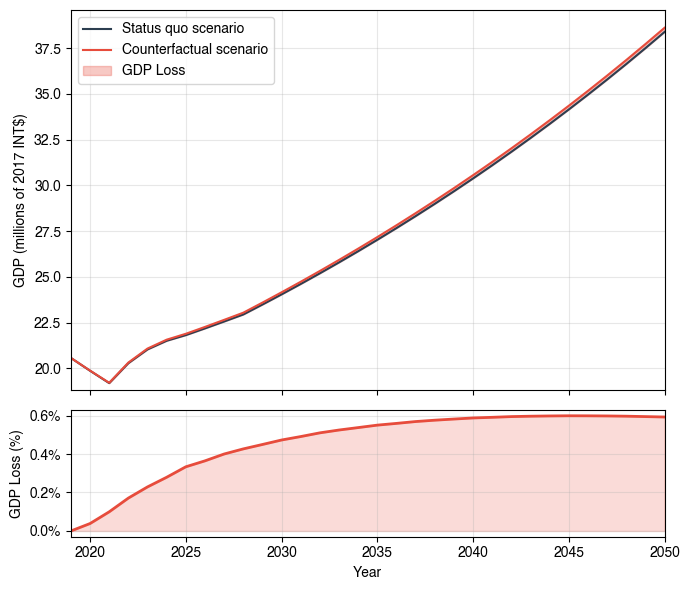

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]

years = usa['year'].values
sq = usa['GDP_SQ'].values / 1e6
cf = usa['GDP_CF'].values / 1e6
loss_pct = (usa['GDP_loss'].values / usa['GDP_SQ'].values) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.plot(years, sq, color='#2c3e50', linewidth=1.5, label='Status quo scenario')
ax1.plot(years, cf, color='#e74c3c', linewidth=1.5, label='Counterfactual scenario')
ax1.fill_between(years, sq, cf, alpha=0.3, color='#e74c3c', label='GDP Loss')
ax1.set_ylabel('GDP (millions of 2017 INT$)')
ax1.set_ylim(bottom=sq.min() * 0.98)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}'))
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

ax2.plot(years, loss_pct, color='#e74c3c', linewidth=2)
ax2.fill_between(years, 0, loss_pct, alpha=0.2, color='#e74c3c')
ax2.set_xlabel('Year')
ax2.set_ylabel('GDP Loss (%)')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax2.set_xlim(2019, 2050)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/figure_3.png', dpi=900, bbox_inches='tight')
plt.savefig('figures/figure_3.pdf', bbox_inches='tight')
plt.savefig('figures/figure_3.svg', bbox_inches='tight')
plt.show()